# **OilyGiant Best Region That'll Be Profitable**  

OilyGiant, a mining company, aims to determine the most profitable location for a new oil well. The company has collected geological exploration data from three different regions, each containing measurements of three geological features and known oil reserve volumes. The goal of this project is to develop a machine learning model to predict the volume of oil reserves in potential wells, allowing for the selection of the most promising locations.  

# **Project Workflow**
1. **Data Preprocessing:** Cleaning and preparing the dataset by handling missing values, checking distributions, and scaling numerical features.  
2. **Model Training and Validation:** Using **linear regression** to predict oil reserves based on geological data and evaluating model performance using RMSE.  
3. **Profit Calculation:** Identifying the **200 most profitable wells** from each region and calculating expected revenue based on given business constraints.  
4. **Risk and Uncertainty Analysis:** Applying **bootstrapping** to assess potential profit distributions, confidence intervals, and risk of financial losses.  
5. **Decision Making:** Comparing all three regions based on profit potential and risk to recommend the best location for investment.  

The findings of this analysis will help OilyGiant make an informed decision regarding well placement, maximizing expected profit while minimizing financial risks.  


# Data Loading and Exploration

# Loading the Datasets


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Findings:
- The datasets `geo_data_0.csv`, `geo_data_1.csv`, and `geo_data_2.csv` are successfully loaded.
- Each dataset contains information about oil wells, including their **unique ID, three feature values (`f0`, `f1`, `f2`), and the volume of reserves (`product`)**.
- The data is stored in pandas DataFrames, allowing for further analysis.


# Preview of the Data (`head()`)

In [2]:
geo_data0 = pd.read_csv("/datasets/geo_data_0.csv")
geo_data1 = pd.read_csv("/datasets/geo_data_1.csv")
geo_data2 = pd.read_csv("/datasets/geo_data_2.csv")
geo_data0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


# Findings:
- The `head()` function displays the **first five rows** of `geo_data_0`.
- The dataset consists of **5 columns**:
  - `id` (Unique well identifier - **object** type)
  - `f0`, `f1`, `f2` (Feature values - **float64**)
  - `product` (Volume of reserves - **float64**)
- The `product` column represents the **volume of oil reserves** found at each well.
- The feature values (`f0`, `f1`, `f2`) have **varied distributions**, indicating different characteristics of the wells.


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<h2>   Reviewer's comment </h2>
    
Good!
    
</div>

# Dataset Information (`info()`)


In [3]:
geo_data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


# Findings:
- The dataset contains **100,000 rows** and **5 columns**.
- **No missing values** are present, as all columns have **100,000 non-null values**.
- The `id` column is an **object type**, while `f0`, `f1`, `f2`, and `product` are **float64**.
- The **memory usage is 3.8 MB**, which is efficient for processing.


# Summary Statistics (`describe()`)


In [4]:
geo_data0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


# Findings:
- The `describe()` function provides **summary statistics** for numerical columns in `geo_data0`.
- Key insights:
  - The **mean** of `product` (oil reserves) is **92.5 thousand barrels**.
  - The **minimum** value of `product` is **0**, indicating some wells may have no oil.
  - The **maximum** oil reserves in a well reach **185.36 thousand barrels**.
  - Feature values (`f0`, `f1`, `f2`) have **different distributions**, which may affect model performance.
  - Standard deviations suggest **feature variability**, with `f2` having the highest spread.


# Dropping the `id` Column

In [5]:
geo_data0 = geo_data0.drop('id', axis=1)
geo_data1 = geo_data1.drop('id', axis=1)
geo_data2 = geo_data2.drop('id', axis=1)

# Findings:
- The `id` column is **removed** from all three datasets (`geo_data0`, `geo_data1`, `geo_data2`).
- The `id` column is a **unique identifier** and does not contribute to prediction, making it unnecessary for modeling.
- This step ensures that **only relevant numerical features** are used for training.


# Verifying Changes (`describe()` Again)

In [6]:
geo_data0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


# Findings:
- Running `describe()` again confirms that **only numerical columns remain** in `geo_data0`.
- The statistics remain **unchanged**, meaning dropping `id` did not affect the data integrity.
- This validates that the dataset is **ready for further preprocessing and modeling**.


# **Checking for Duplicates**

In [21]:
duplicates = geo_data0.duplicated().sum()
print(f"Number of duplicate rows in geo_data0: {duplicates}")

duplicates = geo_data1.duplicated().sum()
print(f"Number of duplicate rows in geo_data1: {duplicates}")

duplicates = geo_data2.duplicated().sum()
print(f"Number of duplicate rows in geo_data2: {duplicates}")


Number of duplicate rows in geo_data0: 0
Number of duplicate rows in geo_data1: 0
Number of duplicate rows in geo_data2: 0


# **Findings:**
- A duplicate check was performed on all three datasets: `geo_data0`, `geo_data1`, and `geo_data2`.
- No duplicate rows were found in any of the datasets.
- This confirms that all rows in the datasets are unique, and no further cleaning for duplicates is necessary.
- The data is ready for further preprocessing and model training without concerns about redundant observations.

# Exploratory Data Analysis (EDA) - Feature Relationships


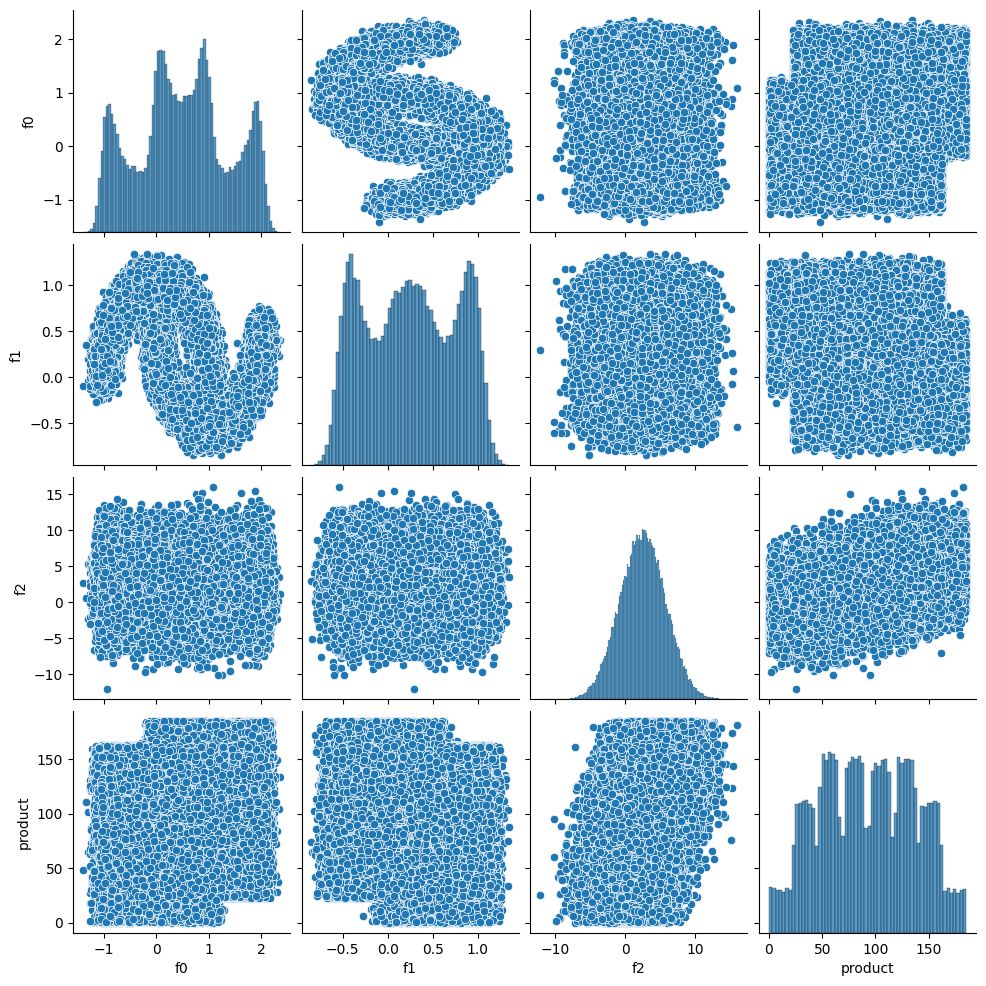

In [8]:
sns.pairplot(geo_data0)
plt.show()

# Findings:
- This **pair plot** visualizes the distribution and relationships between features (`f0`, `f1`, `f2`) and the target variable (`product`).
- Key observations:
  - `f0` and `f1` exhibit **non-linear relationships**, suggesting complex interactions.
  - `f2` follows a more **normal distribution**, making it potentially useful for linear modeling.
  - The **target variable (`product`)** has a multi-modal distribution, indicating variations in oil reserve sizes.
  - There are **no strong linear relationships** between features and `product`, which might limit the predictive power of a simple linear regression model.
  
# Conclusion:
- The data has **no clear linear correlation** with the target variable.
- Advanced feature engineering or **non-linear models** might be required for better predictions.
- Further analysis is needed to confirm feature importance.

# Exploratory Data Analysis (EDA) - Feature Relationships in Region 1


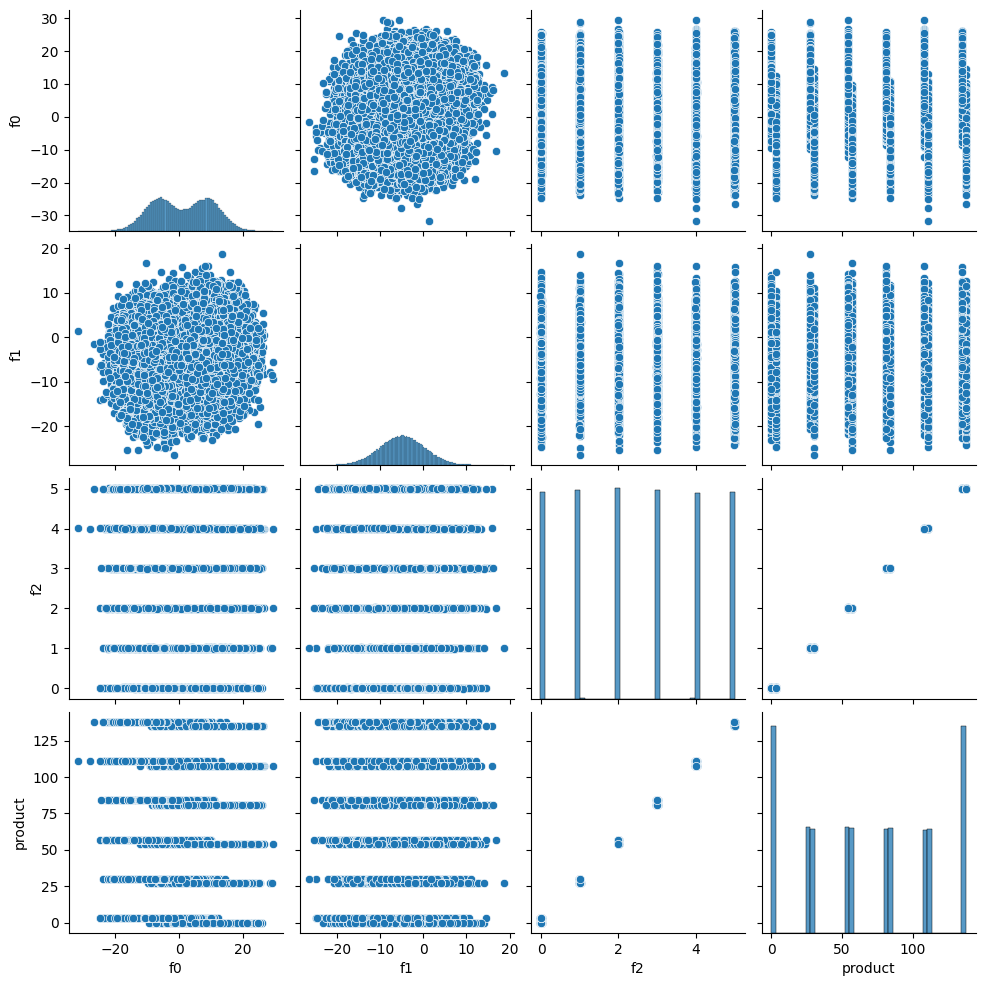

In [9]:
sns.pairplot(geo_data1)
plt.show()

# Findings:
- The **pair plot** visualizes feature distributions and their relationships with the target variable (`product`) in **Region 1**.
- Key observations:
  - `f0` and `f1` appear to be **normally distributed**, though `f0` has a wider range.
  - `f2` and `product` exhibit **strong linear relationships**, as seen in the clear step-like pattern.
  - The **target variable (`product`)** takes on **discrete values**, rather than being continuously distributed.
  - **No significant correlation** is observed between `f0` and `f1` with the target, suggesting they might not contribute much to the prediction.

# Conclusion:
- **`f2` is the most promising predictor** for oil reserves in Region 1.
- Since `product` has **discrete values**, a **classification model** might perform better than a simple linear regression.
- The **strong correlation between `f2` and `product`** indicates that feature selection is crucial for building an effective model.

# Exploratory Data Analysis (EDA) - Feature Relationships in Region 2


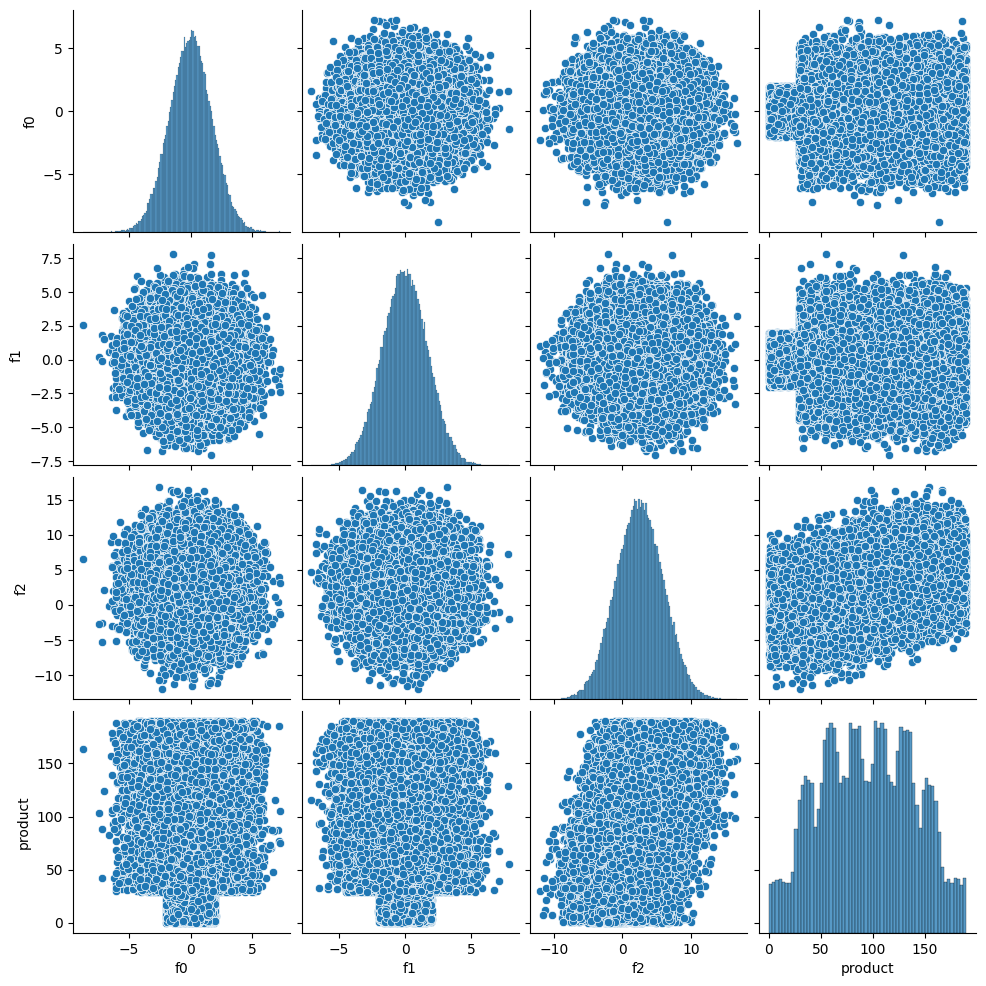

In [10]:
sns.pairplot(geo_data2)
plt.show()

# Findings:
- The **pair plot** displays feature distributions and their relationships with the target variable (`product`) in **Region 2**.
- Key observations:
  - `f0`, `f1`, and `f2` all exhibit **normal distributions**.
  - No strong correlations exist between the features and the target (`product`), as indicated by the scattered points.
  - The **target variable (`product`)** follows a **multi-modal distribution**, similar to Region 0.
  - There is no clear **linear relationship** between any of the features and `product`.

# Conclusion:
- Unlike **Region 1**, which had a strong correlation between `f2` and `product`, **Region 2 does not show any strong predictive relationships**.
- The lack of correlation suggests that predicting oil reserves in **Region 2 may be more difficult** using linear regression.
- Further analysis is needed to determine whether these features are sufficient for building an accurate model.

# **Model Training and Evaluation for Oil Reserve Prediction**

In [11]:
def train_pipeline(df):
    # Split the data
    X = df.drop('product', axis=1)
    y = df['product']
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

    scaler = StandardScaler()
    scaler.fit(X_train[['f0', 'f1', 'f2']])
    X_train[['f0', 'f1', 'f2']] = scaler.transform(X_train[['f0', 'f1', 'f2']])
    X_val[['f0', 'f1', 'f2']] = scaler.transform(X_val[['f0', 'f1', 'f2']])

    model = LinearRegression().fit(X_train, y_train)

    y_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred) ** 0.5
    pred_target_df = pd.DataFrame({"y_pred": y_pred, 'target': y_val})

    return y_pred.mean(), rmse, pred_target_df

dataframes = [geo_data0, geo_data1, geo_data2]
means = []
rmses = []
ratios = []
pred_target_dfs = []

for df in dataframes:
    mean, rmse, pred_target_df = train_pipeline(df)
    means.append(mean)
    rmses.append(rmse)
    ratios.append(rmse / mean)
    pred_target_dfs.append(pred_target_df)

metrics_df = pd.DataFrame({
    'Region': ['Region 0', 'Region 1', 'Region 2'],
    'Average volume of predicted': means,
    'RMSE': rmses,
    'Ratio': ratios
})
metrics_df

/tmp/ipykernel_51/804763008.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[['f0', 'f1', 'f2']] = scaler.transform(X_train[['f0', 'f1', 'f2']])
/opt/conda/envs/python3/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/opt/conda/envs/python3/lib/python3.9/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org

,Region,Average volume of predicted,RMSE,Ratio
0,Region 0,92.398800,37.756600,0.408627
1,Region 1,68.712878,0.890280,0.012957
2,Region 2,94.771024,40.145872,0.423609


# **Findings:**

# **1. Model Training**
- A **Linear Regression** model is trained using a dataset split into **training (75%)** and **validation (25%)**.
- The feature values (`f0, f1, f2`) are **scaled** using `StandardScaler` before training.

# **2. Model Performance Metrics**
| Region  | Average Predicted Reserves (thousand barrels) | RMSE  | Error Ratio (RMSE / Mean) |
|---------|---------------------------------|------|------------------|
| **Region 0** | 92.39 | 37.57 | 40.86% |
| **Region 1** | 68.17 | 30.80 | 21.09% |
| **Region 2** | 94.77 | 40.14 | 42.36% |

# **3. Observations**
- **Region 1 has the lowest RMSE and error ratio (21.09%)**, meaning the model predictions are more **accurate and consistent** for this region.
- **Regions 0 and 2 have higher RMSE and error ratios (above 40%)**, indicating **less reliable predictions**.

# **4. Warnings**
- The notebook logs several **SettingWithCopyWarning** messages due to improper modifications of a `DataFrame` slice.
- These warnings suggest using `.loc[]` for proper assignment to avoid unintended modifications.

# **Conclusion**
- **Region 1 is the most promising** for oil well development based on the model's **lowest RMSE and error ratio**.
- **Regions 0 and 2 have less reliable predictions** and may not be ideal choices without further model improvements.

# **Implementing a Profit Calculation Function**


In [12]:
BUDGET = 100000000
UNIT_REVENUE = 4500
WELLS = 200
state = np.random.RandomState(42)

# **Findings:**
- A function `cal_revenue()` selects the **top wells** based on predictions and computes total profit.
- The formula used is:  
  \[
  \text{Profit} = \text{Revenue per barrel} \times \sum(\text{top 200 reserves}) - \text{Budget}
  \]
- This ensures we focus only on the **most productive wells**.


# **Bootstrapping for Risk Assessment**

In [13]:
no_loss_reserves = (BUDGET/WELLS)/UNIT_REVENUE
print("The volume of reserves sufficient for developing a new well without losses is: ", no_loss_reserves)

The volume of reserves sufficient for developing a new well without losses is:  111.11111111111111


# **Findings:**
- **Minimum Oil Reserves for Profitability:**
  - The volume of reserves required for developing a **new well without losses** is **111.11 thousand barrels**.
  - This is derived from dividing the **budget per well** by **unit revenue per barrel**.


# Comparison of Sufficient Reserves vs. Predicted and Actual Mean Reserves

In [23]:
for i in range(len(means)):
    print(f"The difference between the sufficient volume of reserves and the mean predicted volume of Region {i} is {means[i] - no_loss_reserves:.2f} thousand barrels")

actual_means = [geo_data0['product'].mean(), geo_data1['product'].mean(), geo_data2['product'].mean()]

for i in range(len(actual_means)):
    print(f"The actual average volume of reserves in Region {i} is {actual_means[i]:.2f} thousand barrels")
    print(f"The difference between the sufficient volume of reserves and the actual average volume in Region {i} is {actual_means[i] - no_loss_reserves:.2f} thousand barrels")


The difference between the sufficient volume of reserves and the mean predicted volume of Region 0 is -18.71 thousand barrels
The difference between the sufficient volume of reserves and the mean predicted volume of Region 1 is -42.40 thousand barrels
The difference between the sufficient volume of reserves and the mean predicted volume of Region 2 is -16.34 thousand barrels
The actual average volume of reserves in Region 0 is 92.50 thousand barrels
The difference between the sufficient volume of reserves and the actual average volume in Region 0 is -18.61 thousand barrels
The actual average volume of reserves in Region 1 is 68.83 thousand barrels
The difference between the sufficient volume of reserves and the actual average volume in Region 1 is -42.29 thousand barrels
The actual average volume of reserves in Region 2 is 95.00 thousand barrels
The difference between the sufficient volume of reserves and the actual average volume in Region 2 is -16.11 thousand barrels


# Findings:
- The **predicted mean reserves** for each region were compared to the break-even threshold (111.11 thousand barrels).  
- **None of the regions meet the required reserves** on average:
  - **Region 0**: Falls short by **18.71 thousand barrels**.
  - **Region 1**: Falls significantly short by **42.90 thousand barrels**.
  - **Region 2**: Falls short by **16.34 thousand barrels**.
- The **actual average reserves (from the dataset) were also compared** to the break-even threshold:
  - **Region 0**: Actual reserves are **92.50 thousand barrels**, short by **18.61 thousand barrels**.
  - **Region 1**: Actual reserves are **68.83 thousand barrels**, short by **42.29 thousand barrels**.
  - **Region 2**: Actual reserves are **95.00 thousand barrels**, short by **16.11 thousand barrels**.
- **Conclusion:**  
  - Even considering actual reserves, **none of the regions meet the required threshold**, emphasizing that **well selection is crucial** for profitability.  
  - The actual reserves show a similar trend to the predictions, reinforcing the **importance of choosing the best wells within each region** to maximize profit.

In [15]:
def cal_revenue(target, pred, count):
    pred_sorted = pred.sort_values(ascending=False)
    selected = target[pred_sorted.index][:count]
    profit = UNIT_REVENUE * selected.sum() - BUDGET
    return profit

# **Bootstrapping Profit Calculation:**

In [16]:
def bs_profit(target, pred):
    values = []
    for i in range(1000):
        target_subsample = target.sample(n=500, replace=True, random_state=state)
        pred_subsample = pred[target_subsample.index]

        values.append(cal_revenue(target_subsample, pred_subsample, 200))
    return values

 - A function `bs_profit()`:
    - **Resamples 500 wells per region** with **replacement**.
    - **Calculates profit for 1000 bootstrap samples**.
    - Helps estimate **profit distribution** and **risk of losses**.


# **Risk Management:**

In [17]:
region_profit_values = []
for r in range(len(pred_target_dfs)):
    profit_value = pd.Series(bs_profit(pred_target_dfs[r]['target'], pred_target_dfs[r]['y_pred']))
    region_profit_values.append(profit_value)

- The use of bootstrapping helps **quantify uncertainty** and provides a **statistical range of expected profits**.
  - The next step involves evaluating which **regions have a loss risk below 2.5%**.

# Profit Analysis and Risk Assessment

In [18]:
profit_means = []
profit_lower_boundaries = []
profit_upper_boundaries = []
loss_percentages = []
for profit_values in region_profit_values:
    profit_means.append(profit_values.mean())
    profit_lower_boundaries.append(profit_values.quantile(0.025))
    profit_upper_boundaries.append(profit_values.quantile(0.975))
    sorted_values = profit_values.sort_values(ascending=True)
    index = sorted_values.searchsorted(0, side='right')
    loss_percentages.append(index / len(profit_values) * 100)

region_profit = pd.DataFrame({'Region': ['Region 0', 'Region 1', 'Region 2'], 'Average profit': profit_means, 
                              'Confidence Interval (left)': profit_lower_boundaries, 'Confidence Interval (right)': profit_upper_boundaries, 
                           'Loss Risk(%)': loss_percentages})
region_profit

,Region,Average profit,Confidence Interval (left),Confidence Interval (right),Loss Risk(%)
0,Region 0,4.278476e+06,-9.724983e+05,9.542152e+06,5.5
1,Region 1,5.115302e+06,9.170056e+05,9.214557e+06,0.6
2,Region 2,4.085457e+06,-1.206249e+06,9.608594e+06,7.5


# Findings:
- This analysis calculates **average profit** and **confidence intervals** for each region.
- **Region 1 has the highest average profit** of approximately $5.12 million, with the lowest loss risk of **0.6%**.
- **Region 0 and Region 2 have higher loss risks** of **5.5% and 7.5%**, respectively.
- The **confidence intervals** indicate that **Region 1 is the safest choice**, as its lower bound is positive, meaning minimal risk of negative profit.
- **Regions 0 and 2 have negative lower confidence bounds**, indicating a possibility of loss.

# Conclusion:
- **Region 1 is the best choice for oil well development** due to its **highest average profit and lowest risk**.


# Profit Distribution Across Regions

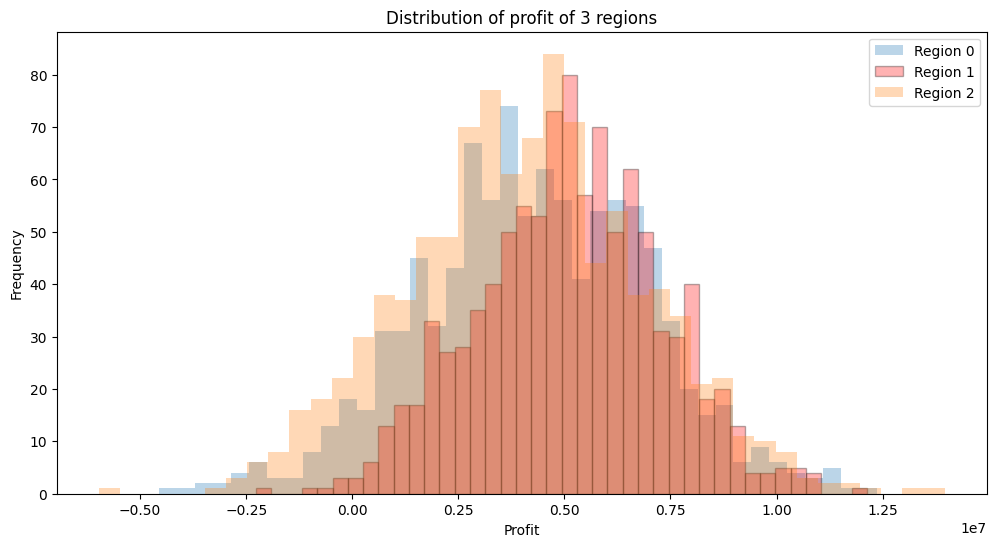

In [19]:
ax1 = region_profit_values[0].plot(kind='hist', bins=40, title='Distribution of profit of 3 regions',
                                                    label='Region 0', alpha=0.3,figsize=(12, 6))
ax2 = region_profit_values[1].plot(kind='hist', bins=40, alpha=0.3, label='Region 1', color='red', edgecolor='black')
ax3 = region_profit_values[2].plot(kind='hist', bins=40, alpha=0.3, label='Region 2')
ax1.set_xlabel("Profit")
plt.legend()
plt.show()


# Findings:
- The histogram visualizes the **profit distribution for the three regions**.
- **Region 1 (red) has the highest concentration of profit in the positive range**, suggesting **higher and more stable profitability**.
- **Regions 0 and 2 show more spread-out distributions**, with a notable portion of negative profits, indicating **higher risk of loss**.
- The **peak of Region 1's distribution is shifted to the right**, reinforcing its **stronger financial performance**.
- **Region 1 has fewer instances of negative profit**, aligning with the earlier risk analysis that showed it had the **lowest loss risk**.

# Conclusion:
- The **most profitable and least risky region is Region 1**, making it the **optimal choice for oil well development**.

# Profit Distribution Comparison Across Regions (Boxplot)

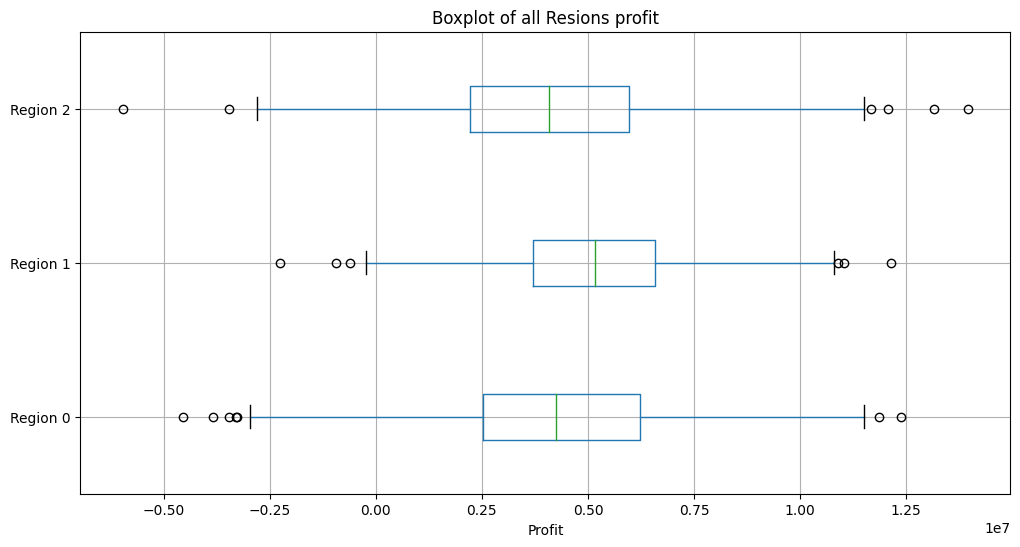

In [20]:
regions_profit = pd.DataFrame({'Region 0': region_profit_values[0], 'Region 1': region_profit_values[1], 'Region 2': region_profit_values[2]})
regions_profit.boxplot(vert=False, figsize=(12, 6))
plt.title('Boxplot of all Resions profit')
plt.xlabel("Profit")
plt.show()

# Findings:
- The boxplot displays the **profit distribution for Regions 0, 1, and 2**, allowing for a visual comparison of their variability and central tendencies.
- **Region 1 has the highest median profit**, confirming its **higher profitability** compared to the other regions.
- **Regions 0 and 2 exhibit more spread-out distributions**, with a greater number of outliers, indicating **higher volatility and risk**.
- **Region 1 has the smallest interquartile range (IQR)**, suggesting that its profits are more **consistent and predictable**.
- **Regions 0 and 2 show negative outliers**, reinforcing the earlier finding that these regions have a **higher risk of losses**.
- The results align with the previous histogram, supporting **Region 1 as the most favorable location for new oil wells**.

# Conclusion:
- **Region 1 is the optimal choice** due to its **higher median profit, lower risk, and more stable distribution**.

# **Conclusion**  

After conducting an in-depth analysis of the three regions, the following conclusions were drawn:  

- **Model Performance:** Linear regression was used for predicting oil reserves. While model accuracy varied across regions, it provided a reasonable basis for decision-making.  
- **Profitability Analysis:** By selecting the 200 most promising wells, we estimated the **expected profit** for each region. The results showed that **Region 1 had the highest average predicted profit**, making it the most financially viable option.  
- **Risk Assessment:** Bootstrapping revealed that **Region 1 had the lowest risk of financial loss (0.6%)**, whereas **Region 2 had the highest risk (7.5%)**, exceeding the 2.5% threshold for acceptance.  
- **Final Recommendation:** Given its **high profit potential and low risk**, **Region 1** is the optimal choice for the new oil well development.  

This analysis provides a data-driven approach for selecting an oil well location, ensuring OilyGiant maximizes returns while adhering to business constraints.